In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import numpy as np
import pandas as pd


df = pd.DataFrame({
    "ore_studio": [5, 10, 15, 8, 12, 7, 14, 9, 11, 16],
    "voto":      [22, 26, 30, 24, 28, 23, 29, 25, 27, 30],
    "corso":     ["Informatica", "Economia", "Ingegneria", "Informatica", "Economia",
                  "Ingegneria", "Informatica", "Economia", "Ingegneria", "Informatica"],
    "genere":    ["M", "F", "M", "F", "M", "F", "M", "F", "M", "F"],
    "anno":      [1, 1, 2, 2, 3, 3, 1, 2, 3, 1]
})

sns.set_theme(style="whitegrid")
def augment_df(base: pd.DataFrame, k: int = 35, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    reps = pd.concat([base] * k, ignore_index=True)
    reps["ore_studio"] = np.clip(reps["ore_studio"].to_numpy() + rng.normal(0, 0.9, size=len(reps)), 1.0, None)
    reps["voto"] = np.clip(reps["voto"].to_numpy() + rng.normal(0, 1.1, size=len(reps)), 18.0, 30.0)
    return reps

df_aug = augment_df(df)  # se df è quello da 10 righe
sns.set_theme(style="whitegrid")

print(df_aug)


     ore_studio       voto        corso genere  anno
0      5.274245  22.405192  Informatica      M     1
1      9.064014  26.931242     Economia      F     1
2     15.675406  29.371962   Ingegneria      M     2
3      8.846508  24.895140  Informatica      F     2
4     10.244068  29.175319     Economia      M     3
..          ...        ...          ...    ...   ...
345    5.143086  22.139342   Ingegneria      F     3
346   13.468007  26.447608  Informatica      M     1
347    9.531816  23.939998     Economia      F     2
348    9.576565  25.993328   Ingegneria      M     3
349   17.328354  29.778785  Informatica      F     1

[350 rows x 5 columns]


<Axes: xlabel='ore_studio', ylabel='voto'>

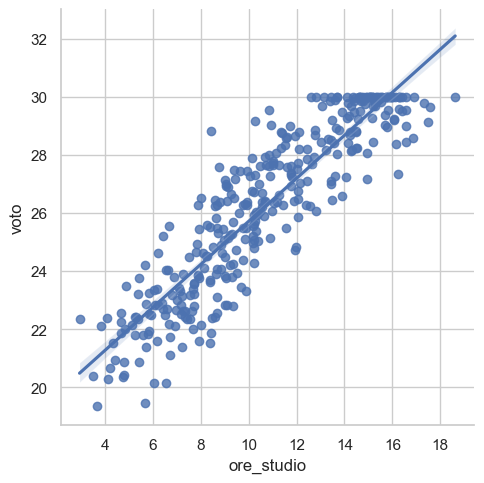

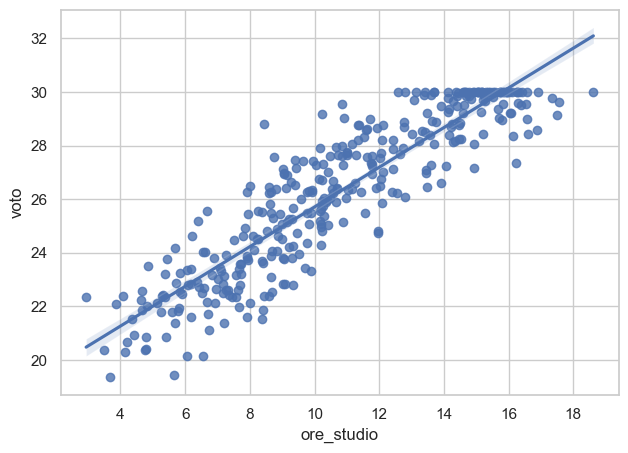

In [7]:
# - ESERCIZIO 1 — lmplot con CI + dimensione punti

sns.lmplot(data=df_aug, x="ore_studio", y="voto", ci=95)


fig, ax = plt.subplots(figsize=(7.2, 5))

sns.regplot(data=df_aug, x="ore_studio", y="voto", )

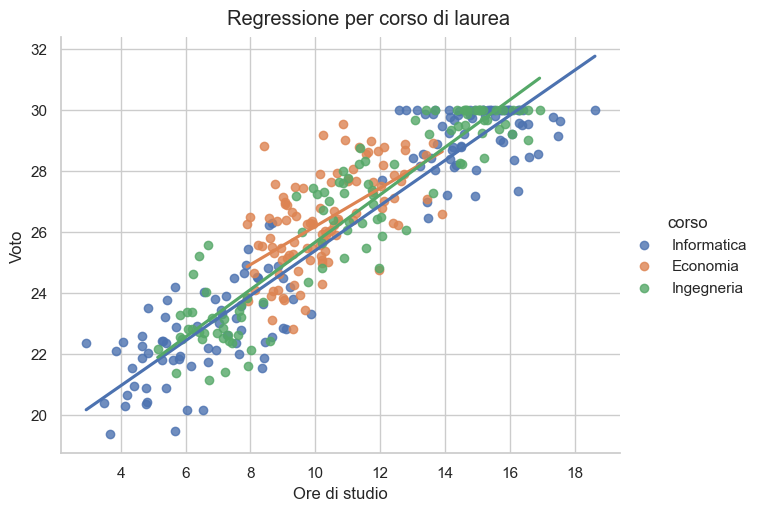

In [8]:
# - ESERCIZIO 2 — Aggiungo hue e confrontimo gruppi

g = sns.lmplot(
    data=df_aug, x="ore_studio", y="voto",
    hue="corso",
    height=5, aspect=1.3,
    ci=None
)
g.set_axis_labels("Ore di studio", "Voto")
g.figure.suptitle("Regressione per corso di laurea", y=1.02)
plt.show()

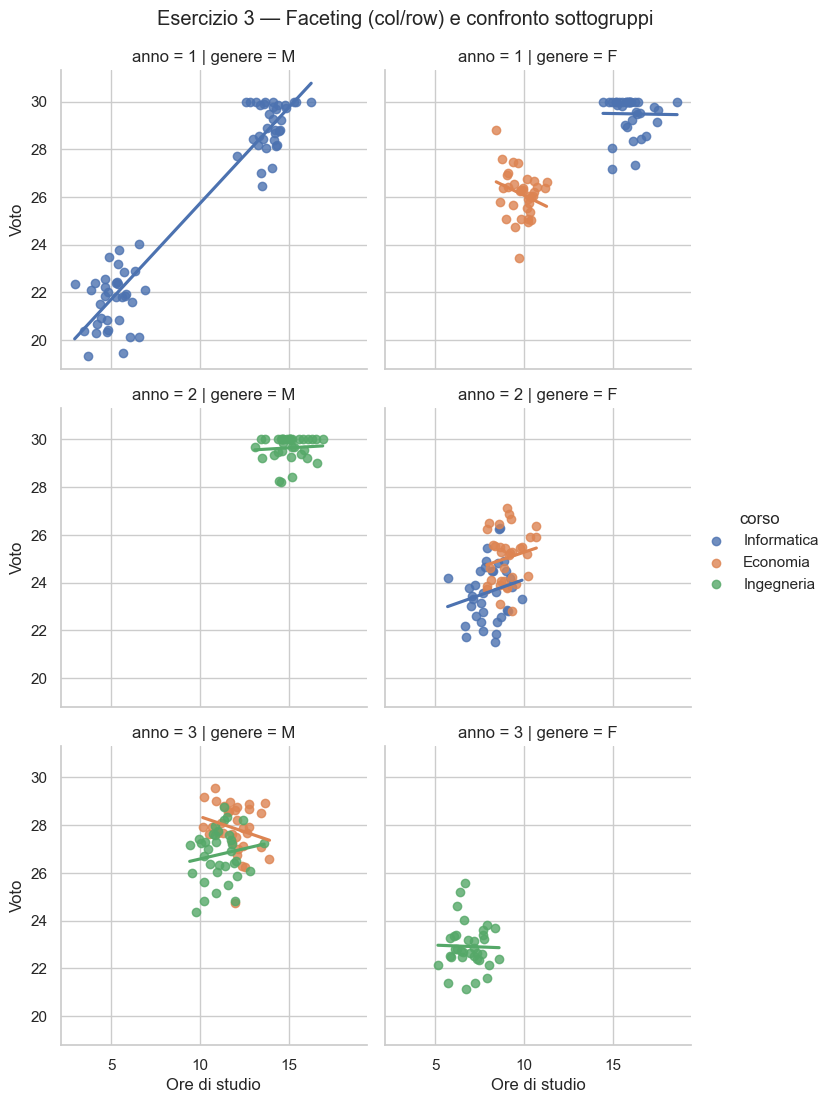

In [9]:
# - ESERCIZIO 3 — Griglia con col e row e interpretazione

g = sns.lmplot(
    data=df_aug, x="ore_studio", y="voto",
    col="genere", row="anno",
    hue="corso",
    ci=None,
    height=3.6
)
g.set_axis_labels("Ore di studio", "Voto")
g.figure.suptitle("Esercizio 3 — Faceting (col/row) e confronto sottogruppi", y=1.02)
plt.show()

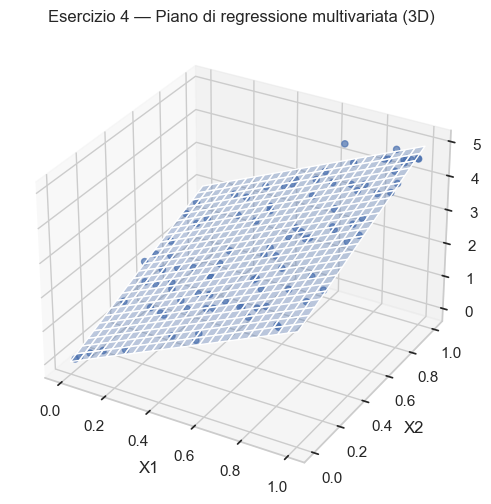

In [10]:
# - ESERCIZIO 4 — Visualizzazione 3D con regressione multivariata continua

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(0)

# Dataset simulato
n = 100
X1 = rng.random(n)
X2 = rng.random(n)
Y  = 3*X1 + 2*X2 + rng.normal(0, 0.2, size=n)

X = np.column_stack([X1, X2])

# Fit modello
model = LinearRegression().fit(X, Y)

# Griglia per il piano
xx, yy = np.meshgrid(np.linspace(0, 1, 25), np.linspace(0, 1, 25))
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1, X2, Y, alpha=0.7)
ax.plot_surface(xx, yy, zz, alpha=0.35)

ax.set_title("Esercizio 4 — Piano di regressione multivariata (3D)")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
plt.show()